In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm
from scipy.stats import pearsonr

os.makedirs("img", exist_ok=True)

In [5]:
scores_path = "data/promoterAI_tss500_TERT.scores.tsv.gz"

TF = pd.read_csv("data/promoterAI_tss500_TERT.promoterAI_v1_hg38_mm10_finetune.TF.tsv.gz", sep="\t")

TORCH   = pd.read_csv("data/promoterAI_tss500_TERT.promoterAI_v1_hg38_mm10_finetune.TORCH.tsv.gz", sep="\t")
TF38    = pd.read_csv("data/promoterAI_tss500_TERT.promoterAI_v1_hg38_finetune.TF.tsv.gz",         sep="\t")
TORCH38 = pd.read_csv("data/promoterAI_tss500_TERT.promoterAI_v1_hg38_finetune.TORCH.tsv.gz",      sep="\t")

meta_cols = ["chrom", "pos", "ref", "alt", "gene", "gene_id", "transcript_id", "strand", "tss_pos"]
out = TF[meta_cols].copy()
out["tf_hg38_mm10_score"]    = TF["score"]
out["tf_hg38_score"]         = TF38["score"]
out["tf_avg_score"]          = (TF["score"] + TF38["score"]) / 2
out["torch_hg38_mm10_score"] = TORCH["score"]
out["torch_hg38_score"]      = TORCH38["score"]
out["torch_avg_score"]       = (TORCH["score"] + TORCH38["score"]) / 2
out.to_csv(scores_path, sep="\t", index=False)

out

,chrom,pos,ref,alt,gene,gene_id,transcript_id,strand,tss_pos,tf_hg38_mm10_score,tf_hg38_score,tf_avg_score,torch_hg38_mm10_score,torch_hg38_score,torch_avg_score
0,chr5,1294488,C,A,TERT,ENSG00000164362,ENST00000334602.10,-1,1294988,0.029691,0.072672,0.051181,0.029691,0.072672,0.051181
1,chr5,1294488,C,G,TERT,ENSG00000164362,ENST00000334602.10,-1,1294988,-0.000300,-0.003400,-0.001850,-0.000300,-0.003400,-0.001850
2,chr5,1294488,C,T,TERT,ENSG00000164362,ENST00000334602.10,-1,1294988,-0.007200,-0.037982,-0.022591,-0.007200,-0.037982,-0.022591
3,chr5,1294489,C,A,TERT,ENSG00000164362,ENST00000334602.10,-1,1294988,0.009600,-0.022196,-0.006298,0.009600,-0.022196,-0.006298
4,chr5,1294489,C,G,TERT,ENSG00000164362,ENST00000334602.10,-1,1294988,0.018098,-0.012999,0.002549,0.018098,-0.012999,0.002549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6001,chr5,1295566,C,G,TERT,ENSG00000164362,ENST00000310581.10,-1,1295067,-0.092733,-0.038281,-0.065507,-0.092733,-0.038281,-0.065507
6002,chr5,1295566,C,T,TERT,ENSG00000164362,ENST00000310581.10,-1,1295067,-0.110645,-0.050457,-0.080551,-0.110645,-0.050457,-0.080551
6003,chr5,1295567,G,A,TERT,ENSG00000164362,ENST00000310581.10,-1,1295067,-0.111040,-0.027593,-0.069317,-0.111040,-0.027593,-0.069317
6004,chr5,1295567,G,C,TERT,ENSG00000164362,ENST00000310581.10,-1,1295067,-0.096400,-0.025095,-0.060747,-0.096400,-0.025095,-0.060747


TF score (hg38_mm10) vs Torch score (hg38_mm10): r=1.0000, MAE=0.0000
TF score (hg38) vs Torch score (hg38): r=1.0000, MAE=0.0000
TF avg score vs Torch avg score: r=1.0000, MAE=0.0000
Published score vs TF avg score: r=1.0000, MAE=0.0000
Published score vs Torch avg score: r=1.0000, MAE=0.0000


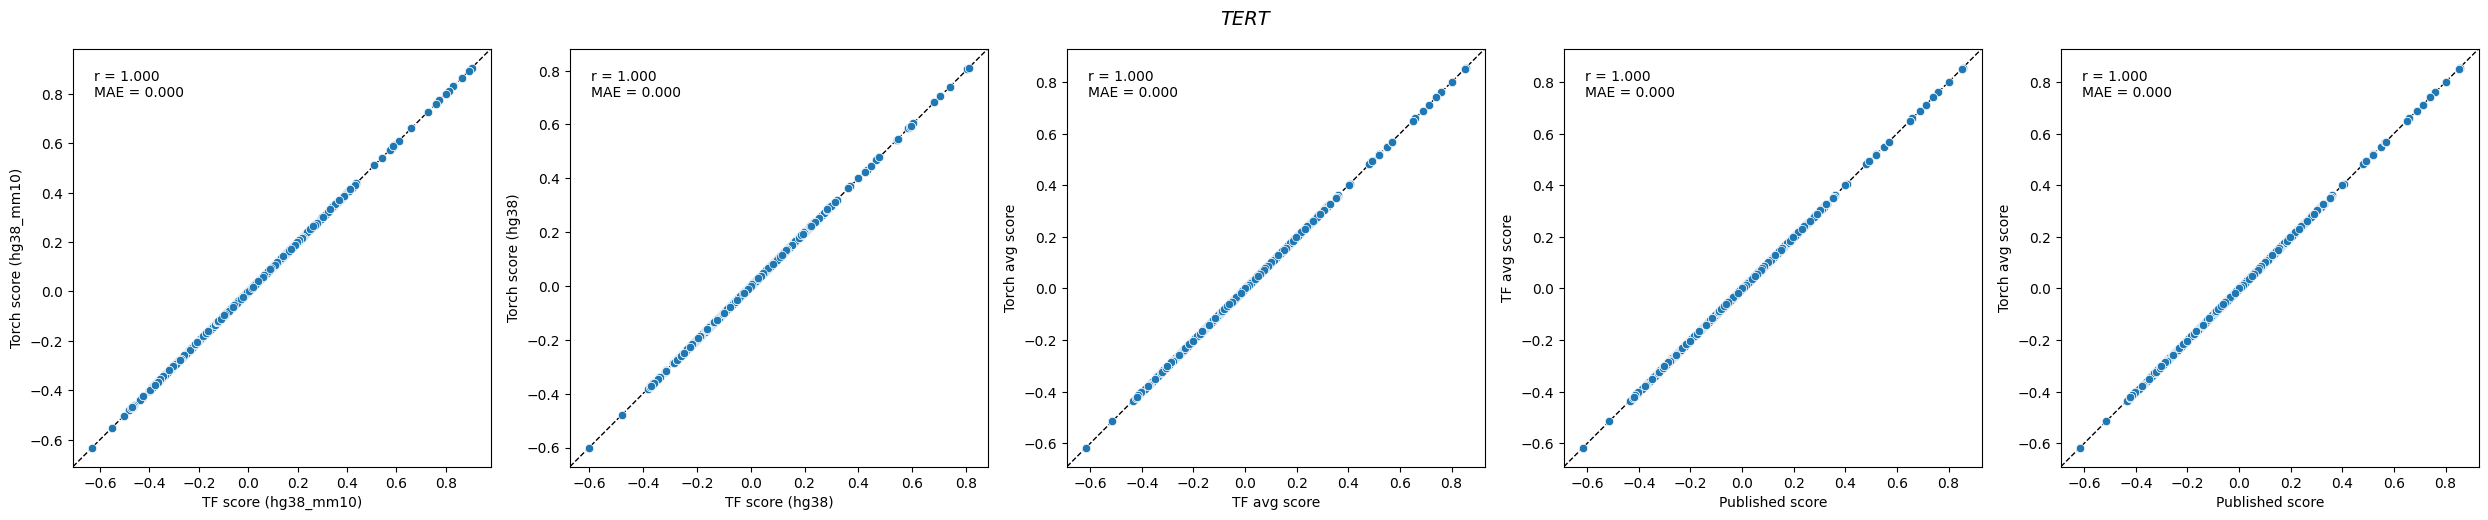

In [11]:
scatter_pairs = [
    (out["tf_hg38_mm10_score"], out["torch_hg38_mm10_score"], "TF score (hg38_mm10)", "Torch score (hg38_mm10)"),
    (out["tf_hg38_score"],      out["torch_hg38_score"],      "TF score (hg38)",      "Torch score (hg38)"),
    (out["tf_avg_score"],       out["torch_avg_score"],       "TF avg score",         "Torch avg score"),
    (TF["promoterAI"],          out["tf_avg_score"],          "Published score",      "TF avg score"),
    (TF["promoterAI"],          out["torch_avg_score"],       "Published score",      "Torch avg score"),
]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("TERT", fontsize=14, fontstyle="italic")
for ax, (x, y, xlabel, ylabel) in zip(axes, scatter_pairs):
    sns.scatterplot(x=x, y=y, ax=ax)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", linewidth=1, zorder=0)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    r, _ = pearsonr(x, y)
    mae = (x - y).abs().mean()
    print(f"{xlabel} vs {ylabel}: r={r:.4f}, MAE={mae:.4f}")
    ax.annotate(f"r = {r:.3f}\nMAE = {mae:.3f}", xy=(0.05, 0.95), xycoords="axes fraction", va="top")

plt.tight_layout()
fig.savefig("img/TERT_scatter.png", bbox_inches="tight")

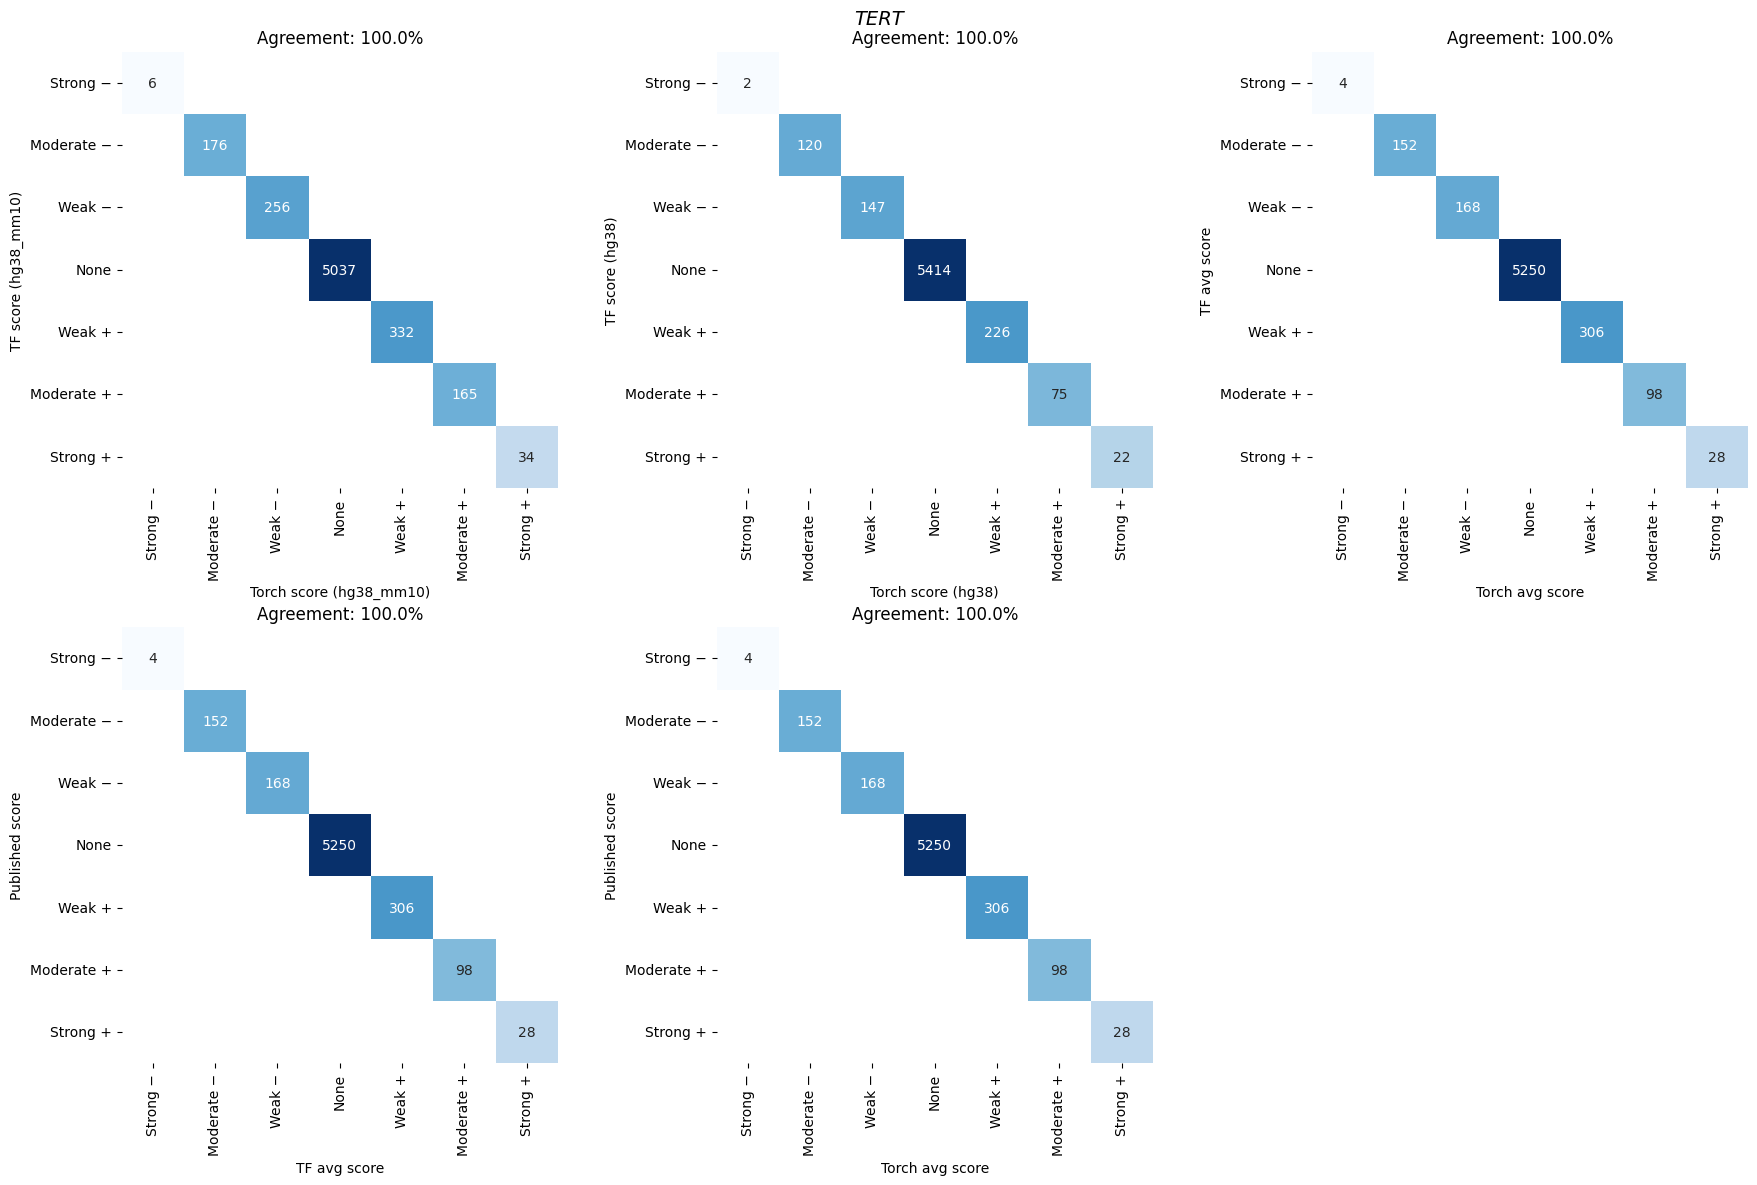

In [10]:
def classify(s):
    bins = [-float("inf"), -0.5, -0.2, -0.1, 0.1, 0.2, 0.5, float("inf")]
    labels = ["Strong −", "Moderate −", "Weak −", "None", "Weak +", "Moderate +", "Strong +"]
    return pd.cut(s, bins=bins, labels=labels)

order = classify(out["tf_hg38_mm10_score"][:1]).cat.categories.tolist()

concordance_pairs = [
    (out["tf_hg38_mm10_score"], out["torch_hg38_mm10_score"], "TF score (hg38_mm10)", "Torch score (hg38_mm10)"),
    (out["tf_hg38_score"],      out["torch_hg38_score"],      "TF score (hg38)",      "Torch score (hg38)"),
    (out["tf_avg_score"],       out["torch_avg_score"],       "TF avg score",         "Torch avg score"),
    (TF["promoterAI"],          out["tf_avg_score"],          "Published score",      "TF avg score"),
    (TF["promoterAI"],          out["torch_avg_score"],       "Published score",      "Torch avg score"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("TERT", fontsize=14, fontstyle="italic")
for ax, (x, y, xlabel, ylabel) in zip(axes.flat, concordance_pairs):
    ct = pd.crosstab(classify(x), classify(y))
    ct = ct.reindex(index=order, columns=order, fill_value=0)
    vmin = ct.values[ct.values > 0].min()
    sns.heatmap(ct, ax=ax, annot=True, fmt="d", cmap="Blues",
                norm=LogNorm(vmin=vmin, vmax=ct.values.max()),
                xticklabels=order, yticklabels=order, cbar=False, square=True)
    ax.set_xlabel(ylabel)
    ax.set_ylabel(xlabel)
    total = ct.values.sum()
    agree = ct.values.diagonal().sum()
    ax.set_title(f"Agreement: {agree/total:.1%}")

axes.flat[-1].set_visible(False)
plt.tight_layout()
fig.savefig("img/TERT_cutoff_concordance.png", bbox_inches="tight")